In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [24]:

data = './BTC-market-analysis_2021-25.csv'
df = pd.read_csv(data)
df = df[["date", "btc_return", "sp500_return", "gold_return"]]

In [25]:
df['date'] = pd.to_datetime(df['date'])
df['date2'] = df['date']

In [26]:
df.set_index('date2', inplace=True)

In [27]:
df = df.loc['2022':]

In [28]:

df = df.replace(0.000000, pd.NA)
df = df.dropna(subset=["sp500_return"])        
df = df.dropna(subset=["gold_return"])  


In [29]:
df["date"]

date2
2022-01-03   2022-01-03
2022-01-04   2022-01-04
2022-01-05   2022-01-05
2022-01-06   2022-01-06
2022-01-07   2022-01-07
                ...    
2026-01-05   2026-01-05
2026-01-06   2026-01-06
2026-01-07   2026-01-07
2026-01-08   2026-01-08
2026-01-09   2026-01-09
Name: date, Length: 1008, dtype: datetime64[us]

In [30]:
size = len(df)
btc_bal = np.empty(size)
sp500_bal = np.empty(size)
gold_bal = np.empty(size)
invested = np.empty(size) 

btc_return = df["btc_return"].values
sp500_return = df["sp500_return"].values
gold_return = df["gold_return"].values

for i in range(size):  
    if i == 0:
        btc_bal[0] = 100
        sp500_bal[0] = 100
        gold_bal[0] = 100      
        invested[0] = 100
        continue
    elif i % 14 == 0:
        btc_bal[i] = btc_bal[i-1] * (1 + btc_return[i-1]) + 100
        sp500_bal[i] = sp500_bal[i-1] * (1 + sp500_return[i-1]) + 100
        gold_bal[i] = gold_bal[i-1] * (1 + gold_return[i-1]) + 100
    else:
        btc_bal[i] = btc_bal[i-1] * (1 + btc_return[i-1])
        sp500_bal[i] = sp500_bal[i-1] * (1 + sp500_return[i-1])
        gold_bal[i] = gold_bal[i-1] * (1 + gold_return[i-1])
    invested[i] = (1 + i // 14) * 100

In [31]:
date = np.array(df["date"])

In [32]:
btc_bal

array([  100.        ,    98.12631225,    96.94236383, ...,
       12486.69222105, 12164.16686464, 12126.74107994], shape=(1008,))

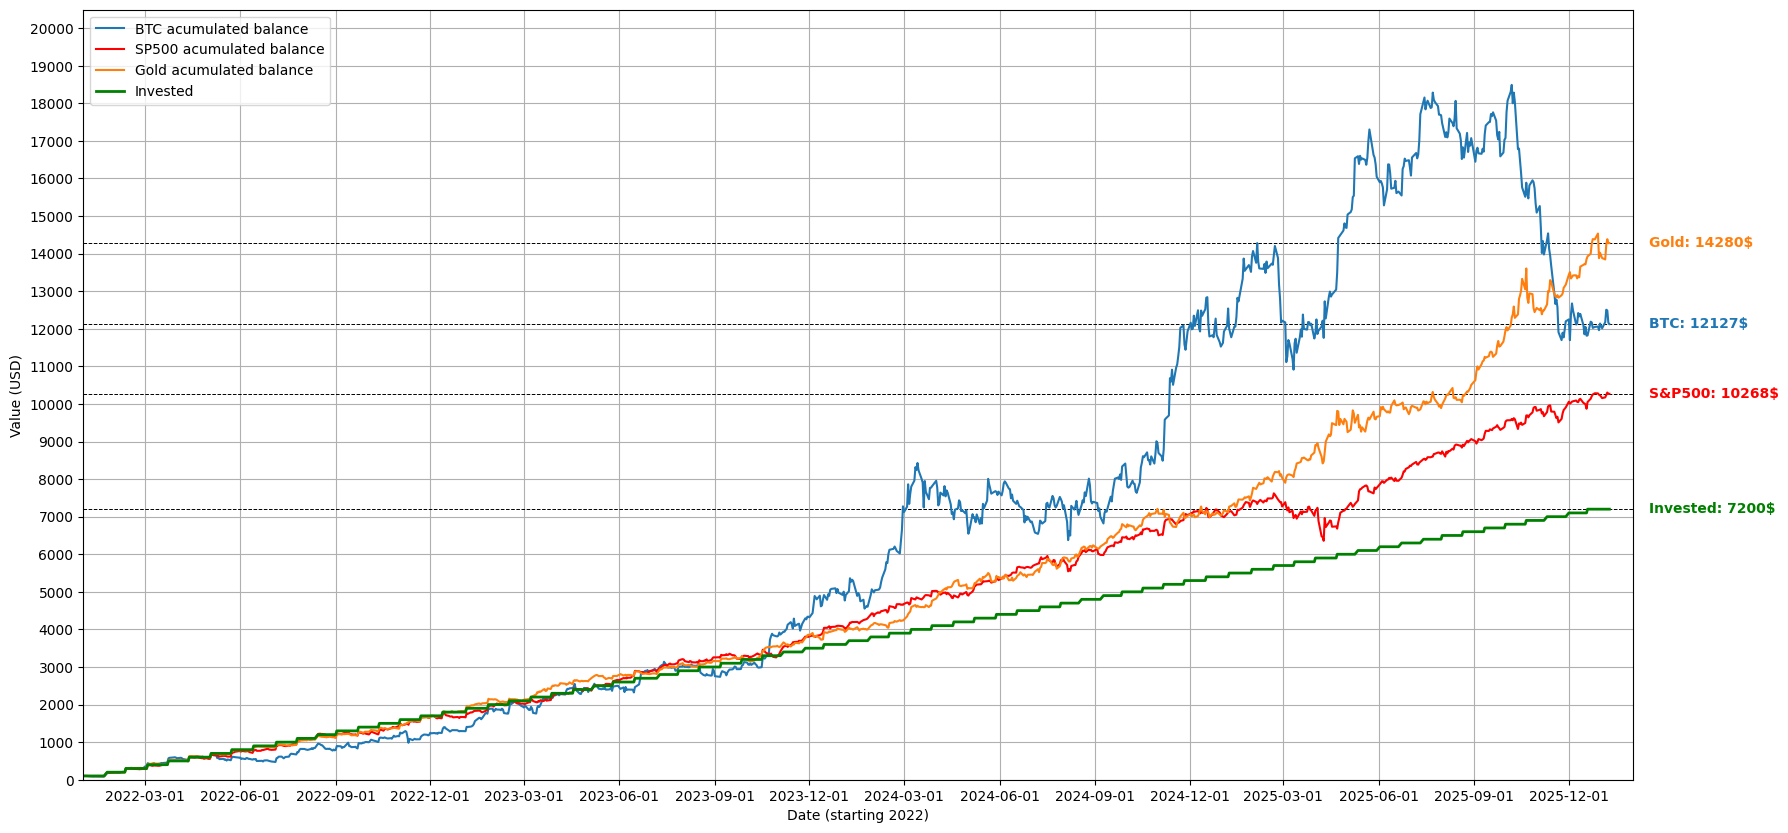

In [33]:
fig, ax = plt.subplots(figsize=(20, 10))

targets = [
    (invested[-1], f'Invested: {invested[-1]:.0f}$', 'green'),
    (sp500_bal[-1], f'S&P500: {sp500_bal[-1]:.0f}$', 'red'),
    (btc_bal[-1], f'BTC: {btc_bal[-1]:.0f}$', 'C0'),
    (gold_bal[-1], f'Gold: {gold_bal[-1]:.0f}$', 'C1')
]

for val, label, col in targets:
    ax.axhline(y=val, color='black', linestyle='--', linewidth=0.7)
    # Adiciona o texto à direita
    ax.text(1.01, val, label, transform=ax.get_yaxis_transform(), 
            va='center', ha='left', color=col, fontweight='bold')
# ax.axhline(y=invested[-1], color='black', linestyle='--', linewidth = '0.7')
# ax.axhline(y=sp500_bal[-1], color='black', linestyle='--', linewidth = '0.7')
# ax.axhline(y=btc_bal[-1], color='black', linestyle='--', linewidth = '0.7')
# ax.axhline(y=gold_bal[-1], color='black', linestyle='--', linewidth = '0.7')

ax.plot(date, btc_bal, label='BTC acumulated balance')
ax.plot(date, sp500_bal, label='SP500 acumulated balance', color = 'red')
ax.plot(date, gold_bal, label='Gold acumulated balance')
ax.plot(date, invested, linewidth=2, label = 'Invested', color = 'green')

ax.legend()

ax.grid(axis='y')
ax.grid(axis='x')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlim(pd.to_datetime('2022-01-01'), pd.to_datetime('2026-02')) 
ax.set_ylim(0, 2000 + max([max(btc_bal), max(sp500_bal), max(gold_bal)]))

ax.set_ylabel("Value (USD)")
ax.set_xlabel("Date (starting 2022)")

# ax.text(1.01, invested[-1], f'Invested: {invested[-1]:.0f}$', transform=ax.get_yaxis_transform(), va='center', ha='left', color='green', fontweight='bold')

plt.show()